# AI-Driven Educational Quiz Platform Generator

This  system can transforms user-specified subjects and knowledge points into a fully functional online quiz platform. Given a topic (e.g., "Python Basics: variables, loops, functions"), the system automatically generates a Flask API with question bank management, random quiz generation, auto-scoring, and grade statistics — along with an interactive frontend featuring quiz pages, result analysis, wrong-answer review, and an AI-generated knowledge mind map image.

The system follows the AI-DLC Methodology.

## Setup & Environment
Load environment, import utilities, initialize LLM client for the Quiz Platform Generator.

In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

# Ensure required dependency for Quiz Platform utils is available
try:
    from PIL import Image  # noqa: F401
    print("✅ Pillow already installed")
except Exception:
    print("Installing Pillow...")
    %pip install pillow
    
# Ensure local imports work
from utils import load_environment, get_completion

# Load environment variables and set up the LLM client
load_environment()
client, model_name, api_provider = None, None, None
try:
    from utils import setup_llm_client, clean_llm_output, recommended_models_table
    client, model_name, api_provider = setup_llm_client("openai/gpt-5.2")
    print(f"✅ LLM Client initialized: {api_provider} - {model_name}")
except Exception as e:
    print(f"❌ Error initializing LLM client: {e}")

✅ Pillow already installed
✅ LLM Client configured: Using 'apifree' with model 'openai/gpt-5.2'
✅ LLM Client initialized: apifree - openai/gpt-5.2


# Phase 1: Inception
Inception is the phase where business intent is converted into execution-ready context. This phase focuses on capturing Intents and translating them into Units for development.

An Intent is a high-level statement of purpose that encapsulates what needs to be achieved, serving as a starting point for the methodology. In this practical, we will be driven by the (1) business problem, (2) personas, (3) requirements, and (4) user stories.

In [2]:
# Define the quiz platform business problem
business_problem = "Our education platform needs an AI-powered system that automatically generates online quiz platforms based on user-specified subjects and knowledge points. The system should support question bank management, random quiz generation with configurable difficulty, auto-scoring with detailed explanations, grade statistics and analytics, a wrong-answer review book for students, and at least one AI-generated knowledge mind map image displayed on the website."

#### 1) AI generated –Business problem

In [10]:
if client and 'business_problem' in globals():
    print("--- Generating Problem Statement ---")
    prompt = f"Given the business problem below, generate one clear and concise problem statement.\nBusiness Problem: {business_problem}"
    problem_statement = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    # Guard: check if API returned an error message
    if problem_statement and not problem_statement.startswith(("An API error", "APIFREE error", "APIFREE request failed", "Error:")):
        print(problem_statement)
    else:
        problem_statement = None
        print("API request failed. Please re-run this cell.")
        print("If it still fails, please check your network connection and try re-running multiple times.")
else:
    print("Skipping step because LLM client or business problem is not available.")

--- Generating Problem Statement ---
Develop an AI-powered quiz generation and assessment system for our education platform that creates subject- and knowledge-point–based online quizzes, manages a question bank, generates randomized quizzes with configurable difficulty, auto-scores with detailed explanations, provides grade analytics, supports a student wrong-answer review book, and displays an AI-generated knowledge mind map image on the website.


#### 2) AI generated –Personas (as in the Agile methodology)

In [11]:
if client and 'problem_statement' in globals():
    print("--- Generating Personas ---")
    prompt = (
        "Generate 2-4 user personas for an educational quiz platform using this format:\n"
        "Personas: <one-sentence intro>\n\n"
        "1. **Role Title**\n   - **Responsibilities:** ...\n   - **Needs:** ...\n\n"
        "2. **Role Title**\n   - **Responsibilities:** ...\n   - **Needs:** ...\n\n"
        "Rules: Use single role titles only; no slashes (/) or combined titles. "
        "Include at least one student and one teacher persona. Keep each bullet concise.\n"
        f"Problem Statement: {problem_statement}"
    )
    personas = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    # Guard: check if API returned an error message
    if personas and not personas.startswith(("An API error", "APIFREE error", "APIFREE request failed", "Error:")):
        print(f"Personas: {personas}")
    else:
        personas = None
        print("API request failed. Please re-run this cell.")
        print("If it still fails, please check your network connection and try re-running multiple times.")
else:
    print("Skipping step because LLM client or problem statement is not available.")

--- Generating Personas ---
Personas: Personas: Primary users span learners practicing independently and educators creating, assigning, and analyzing quizzes.

1. **Student**
   - **Responsibilities:** Complete assigned and self-practice quizzes; review mistakes; track progress by topic.
   - **Needs:** Personalized quizzes by knowledge point and difficulty; instant scoring with clear explanations; wrong-answer review book; visible mastery analytics; AI knowledge mind map for study planning.

2. **Teacher**
   - **Responsibilities:** Create and assign quizzes; maintain question bank quality; monitor class performance; provide targeted remediation.
   - **Needs:** AI quiz generation by subject/knowledge point; randomized quiz versions with configurable difficulty; editable question bank with tags; auto-scoring with rationale; grade analytics by student/topic; shareable mind map view for instruction.

3. **Administrator**
   - **Responsibilities:** Manage platform settings, users, and co

#### 3) AI generated –Requirements based on the problem statement and personas

In [13]:
if client and 'problem_statement' in globals() and 'personas' in globals():
    print("--- Generating PRD ---")
    prompt = (
        "Write a PRD for an AI-powered educational quiz platform in markdown with these headings, each with 2-4 concise bullets:\n"
        "## Overview\n## Goals\n## Non-Goals\n## User Personas (brief)\n"
        "## Key Features\n## User Flows\n## Functional Requirements\n"
        "## Non-Functional Requirements\n## Constraints/Assumptions\n"
        "## Success Metrics\n## Open Questions\n\n"
        "Rules: Use only the headings above. No extra sections. Keep bullets short.\n"
        f"Problem Statement: {problem_statement}\n"
        f"Personas: {personas}"
    )
    prd = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3,
    )
    # Guard: check if API returned an error message
    if prd and not prd.startswith(("An API error", "APIFREE error", "APIFREE request failed", "Error:")):
        prd = clean_llm_output(prd, language='markdown')
        print(f"PRD: {prd}")
        os.makedirs('artifacts', exist_ok=True)
        with open('artifacts/prd.md', 'w') as f:
            f.write(prd)
        print('✅ Saved: artifacts/prd.md')
    else:
        prd = None
        print("API request failed. Please re-run this cell.")
        print("If it still fails, please check your network connection and try re-running multiple times.")
else:
    print("Skipping step because LLM client, problem statement, or personas are not available.")

--- Generating PRD ---
PRD: ## Overview
- AI-powered quiz generation and assessment for subject + knowledge-point practice
- Central question bank with tagging, editing, moderation, and reuse
- Randomized quizzes with configurable difficulty and versions per assignment
- Auto-scoring with explanations, analytics, wrong-answer review, and AI mind map image

## Goals
- Enable students to practice targeted knowledge points with instant feedback and mastery tracking
- Help teachers generate/assign high-quality quizzes quickly and analyze outcomes by topic
- Maintain a governed, searchable question bank with auditability and content quality controls
- Provide AI-generated knowledge mind map images to support study planning and instruction

## Non-Goals
- Full LMS replacement (attendance, full course delivery, live teaching)
- Proctoring/anti-cheating beyond basic randomized versions and access controls
- Manual-only content creation workflows (AI-assisted is primary, manual is supported)
- 

#### 4) AI generated –User stories from the PRD and personas

In [14]:
if client and 'prd' in globals():
    print("--- Generating User Stories ---")
    prompt = (
        "Return ONLY valid JSON with this schema:\n"
        "{\n  \"user_stories\": [\n    {\n      \"id\": 1,\n      \"role\": \"<role>\",\n"
        "      \"goal\": \"<goal>\",\n      \"benefit\": \"<benefit>\",\n"
        "      \"acceptance_criteria\": [\"<criteria>\", \"<criteria>\"]\n    }\n  ]\n}\n\n"
        "Rules: Provide 5 stories covering quiz creation, quiz taking, auto-scoring, "
        "wrong-answer review, and grade analytics. Keep each field concise. No extra keys.\n"
        f"PRD: {prd}"
    )
    user_stories = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    # Guard: check if API returned an error message
    if user_stories and not user_stories.startswith(("An API error", "APIFREE error", "APIFREE request failed", "Error:")):
        user_stories = clean_llm_output(user_stories, language='json')
        print(f"User Stories: {user_stories}")
        import json, os
        os.makedirs('artifacts', exist_ok=True)
        user_stories_data = { 'user_stories': user_stories }
        with open('artifacts/user_stories.json', 'w') as f:
            json.dump(user_stories_data, f, indent=2)
        print('✅ Saved: artifacts/user_stories.json')
    else:
        user_stories = None
        print("API request failed. Please re-run this cell.")
        print("If it still fails, please check your network connection and try re-running multiple times.")
else:
    print("Skipping step because LLM client or PRD is not available.")

--- Generating User Stories ---
User Stories: {
  "user_stories": [
    {
      "id": 1,
      "role": "Teacher",
      "goal": "Generate and edit a quiz from selected knowledge points and difficulty mix",
      "benefit": "Create high-quality assignments quickly with reusable questions",
      "acceptance_criteria": [
        "Can input subject, knowledge points, question types, counts, difficulty mix, and time limit",
        "System generates a draft quiz and allows editing, tagging, and saving to the question bank"
      ]
    },
    {
      "id": 2,
      "role": "Student",
      "goal": "Take a randomized quiz version with autosave",
      "benefit": "Practice targeted skills reliably without losing progress",
      "acceptance_criteria": [
        "Quiz loads an assigned version with time limit and randomized order where configured",
        "Answers autosave and the student can resume after refresh within allowed window"
      ]
    },
    {
      "id": 3,
      "role": "Teache

## Phase 2: Construction
Construction is the phase where AI plans and builds the system end-to-end using the established context, with humans validating outcomes. In this practical, we focus on (1) UML diagrams followed by the (2) product code.

#### 1) AI generated –UML diagrams

Use Case Diagram

--- Generating PlantUML Use Case Diagram ---
Generated PlantUML diagram:
@startuml
actor Teacher
actor Student

rectangle "Quiz Platform" {
  usecase "Generate and edit a quiz from selected knowledge points and difficulty mix" as GenerateEditQuiz
  usecase "Take a randomized quiz version with autosave" as TakeRandomizedQuiz
  usecase "Auto-score submissions with per-item explanations and partial credit rules" as AutoScoreSubmissions
  usecase "Review wrong answers and save them to a personal wrong-answer book" as ReviewWrongAnswers
  usecase "View grade analytics by class and knowledge point with an AI mind map image" as ViewGradeAnalytics
}

Teacher -- GenerateEditQuiz
Student -- TakeRandomizedQuiz
Teacher -- AutoScoreSubmissions
Student -- ReviewWrongAnswers
Teacher -- ViewGradeAnalytics
@enduml
✅ Saved: artifacts/diagrams/use_case_diagram.puml
✅ Diagram rendered and saved to: artifacts\artifacts\diagrams\use_case_diagram.png


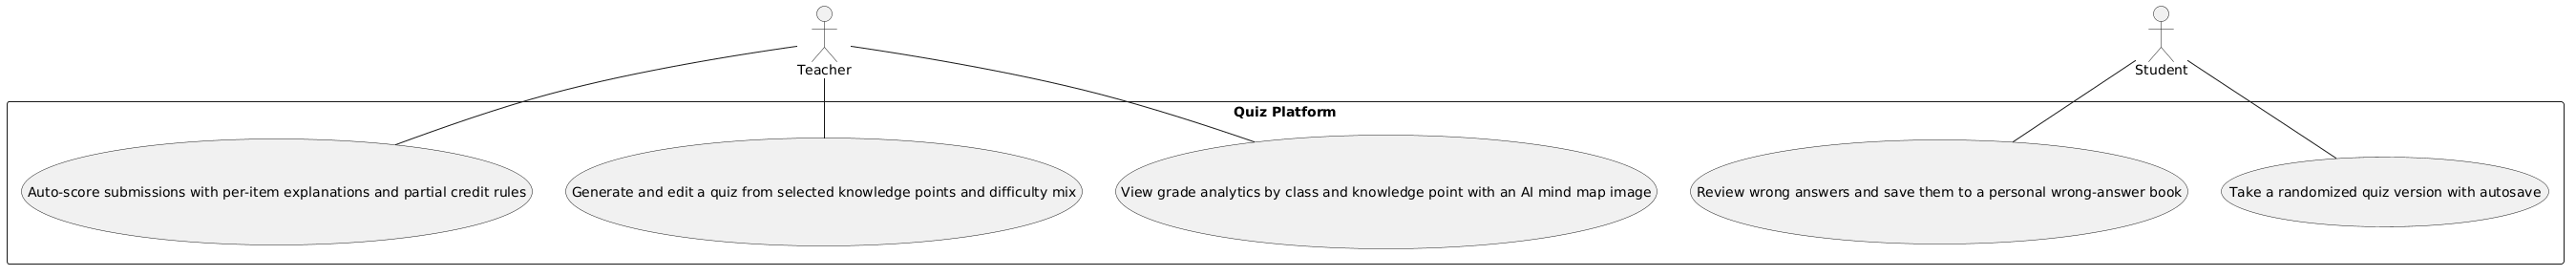

In [15]:
from utils import render_plantuml_diagram

if client and 'user_stories' in globals():
    print("--- Generating PlantUML Use Case Diagram ---")
    prompt = (
        "Create a PlantUML use case diagram for an educational quiz platform.\n\n"
        "Format:\n@startuml\nactor ActorName\n"
        "rectangle \"Quiz Platform\" {\n  usecase \"Verb Noun\" as UC1\n}\n"
        "ActorName -- UC1\n@enduml\n\n"
        "Rules:\n"
        "- Actors outside system boundary (rectangle)\n"
        "- Use cases inside, verb-noun phrases, no numbering\n"
        "- Use -- for associations, ..> for <<include>>/<<extend>>\n"
        "- Extract actors from 'role', use cases from 'goal' fields\n"
        "- Return ONLY valid PlantUML code\n\n"
        f"User Stories: {user_stories}"
    )
    puml = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    # Guard: only save if API returned valid PlantUML code
    if puml and not puml.startswith(("An API error", "APIFREE error", "APIFREE request failed", "Error:")):
        puml = clean_llm_output(puml, language='text')
        print("Generated PlantUML diagram:")
        print(puml)
        os.makedirs('artifacts/diagrams', exist_ok=True)
        with open('artifacts/diagrams/use_case_diagram.puml', 'w') as f:
            f.write(puml)
        print('✅ Saved: artifacts/diagrams/use_case_diagram.puml')
        render_plantuml_diagram(puml, "artifacts/diagrams/use_case_diagram.png")
    else:
        print("API request failed. Please re-run this cell.")
        print("If it still fails, please check your network connection and try re-running multiple times.")
else:
    print("Skipping step because LLM client or user_stories is not available.")

Class Diagram

--- Generating PlantUML Class Diagram ---
Generated PlantUML diagram:
@startuml
class Quiz {
  +quizId: String
  +title: String
  +subject: String
  +knowledgePoints: List<String>
  +difficultyMix: Map<String, Integer>
  +timeLimitMinutes: int
  +randomizeOrder: boolean
  +status: String
  +createdAt: DateTime
  +generateDraft(subject: String, knowledgePoints: List<String>, questionTypes: List<String>, counts: Map<String, int>, difficultyMix: Map<String, Integer>, timeLimitMinutes: int): Quiz
  +editMetadata(title: String, timeLimitMinutes: int, randomizeOrder: boolean): void
  +addQuestion(question: Question): void
  +removeQuestion(questionId: String): void
  +tag(tags: List<String>): void
  +publish(): void
}

class Question {
  +questionId: String
  +type: String
  +prompt: String
  +difficulty: String
  +knowledgePoint: String
  +tags: List<String>
  +points: float
  +partialCreditRule: String
  +explanation: String
  +validate(): boolean
  +shuffleOptions(): void
  +grade(student

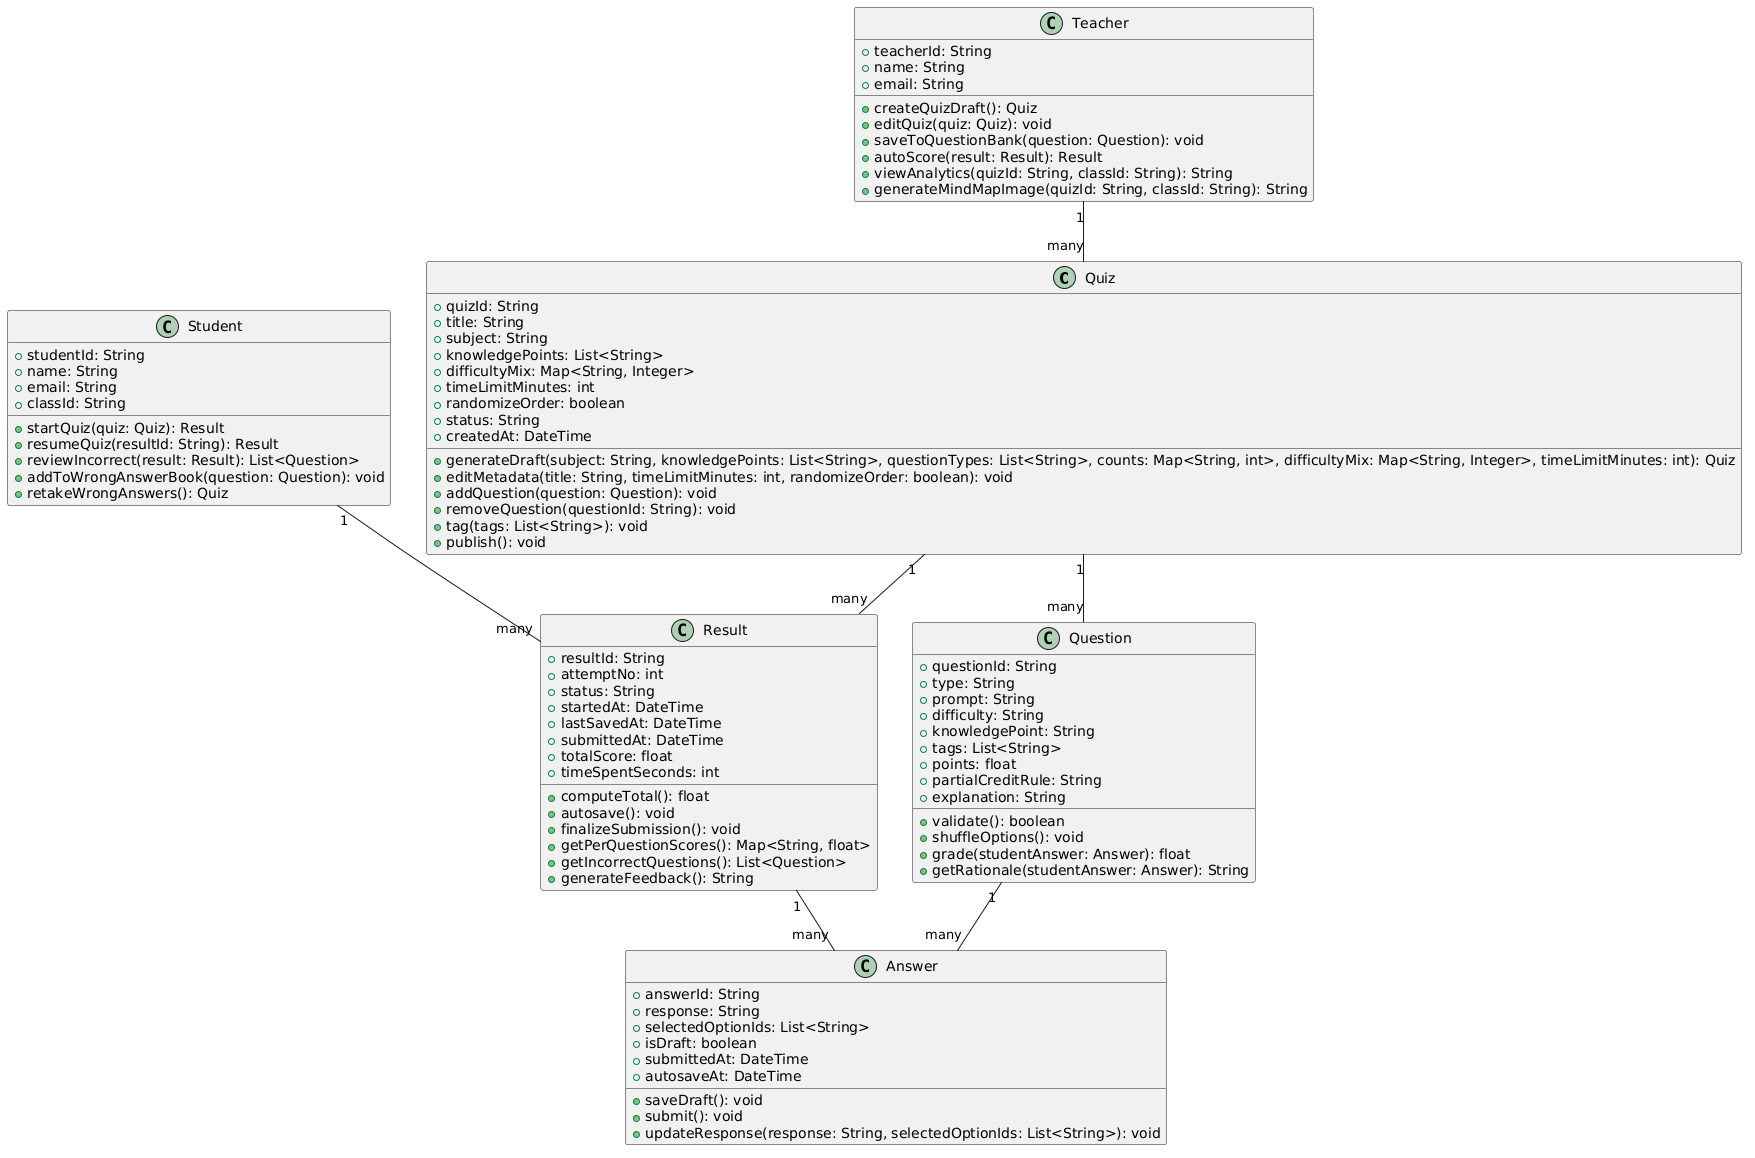

In [16]:
if client and 'user_stories' in globals():
    print("--- Generating PlantUML Class Diagram ---")
    prompt = (
        "Create a PlantUML class diagram for an educational quiz platform.\n\n"
        "Format:\n@startuml\nclass ClassName {\n  +attr: Type\n  +method(): Type\n}\n"
        "ClassName \"1\" -- \"many\" OtherClass\n@enduml\n\n"
        "Rules:\n"
        "- Include: Quiz, Question, Answer, Student, Teacher, Result\n"
        "- Show key attributes and methods per class\n"
        "- Use -- with multiplicities for associations\n"
        "- Return ONLY valid PlantUML code\n\n"
        f"User Stories: {user_stories}"
    )
    puml = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    # Guard: only save if API returned valid PlantUML code
    if puml and not puml.startswith(("An API error", "APIFREE error", "APIFREE request failed", "Error:")):
        puml = clean_llm_output(puml, language='text')
        print("Generated PlantUML diagram:")
        print(puml)
        os.makedirs('artifacts/diagrams', exist_ok=True)
        with open('artifacts/diagrams/class_diagram.puml', 'w') as f:
            f.write(puml)
        print('✅ Saved: artifacts/diagrams/class_diagram.puml')
        render_plantuml_diagram(puml, "artifacts/diagrams/class_diagram.png")
    else:
        print("API request failed. Please re-run this cell.")
        print("If it still fails, please check your network connection and try re-running multiple times.")
else:
    print("Skipping step because LLM client or user_stories is not available.")

Sequence Diagram

--- Generating PlantUML Sequence Diagram ---
Generated PlantUML diagram:
@startuml
actor Student
participant "Quiz API" as API
participant "Autosave Service" as AS
participant "Scoring Engine" as SE
participant "Results Service" as RS
participant "Wrong-Answer Book" as WAB

Student -> API: GET /quiz?assignmentId=...
API -> API: Select randomized version + apply time limit
API --> Student: 200 Quiz (questions, order, timeLimit, attemptId)

loop For each answer (autosave)
  Student -> API: POST /quiz/{attemptId}/answer (questionId, response)
  API -> AS: Save draft answer (attemptId, questionId, response)
  AS --> API: saved (version, timestamp)
  API --> Student: 200 saved (version, timestamp)
end

opt Resume after refresh within window
  Student -> API: GET /quiz/{attemptId}/state
  API -> AS: Load latest saved state (attemptId)
  AS --> API: state (answers, remainingTime)
  API --> Student: 200 state (answers, remainingTime)
end

Student -> API: POST /quiz/{attemptId}/submit
API -> AS

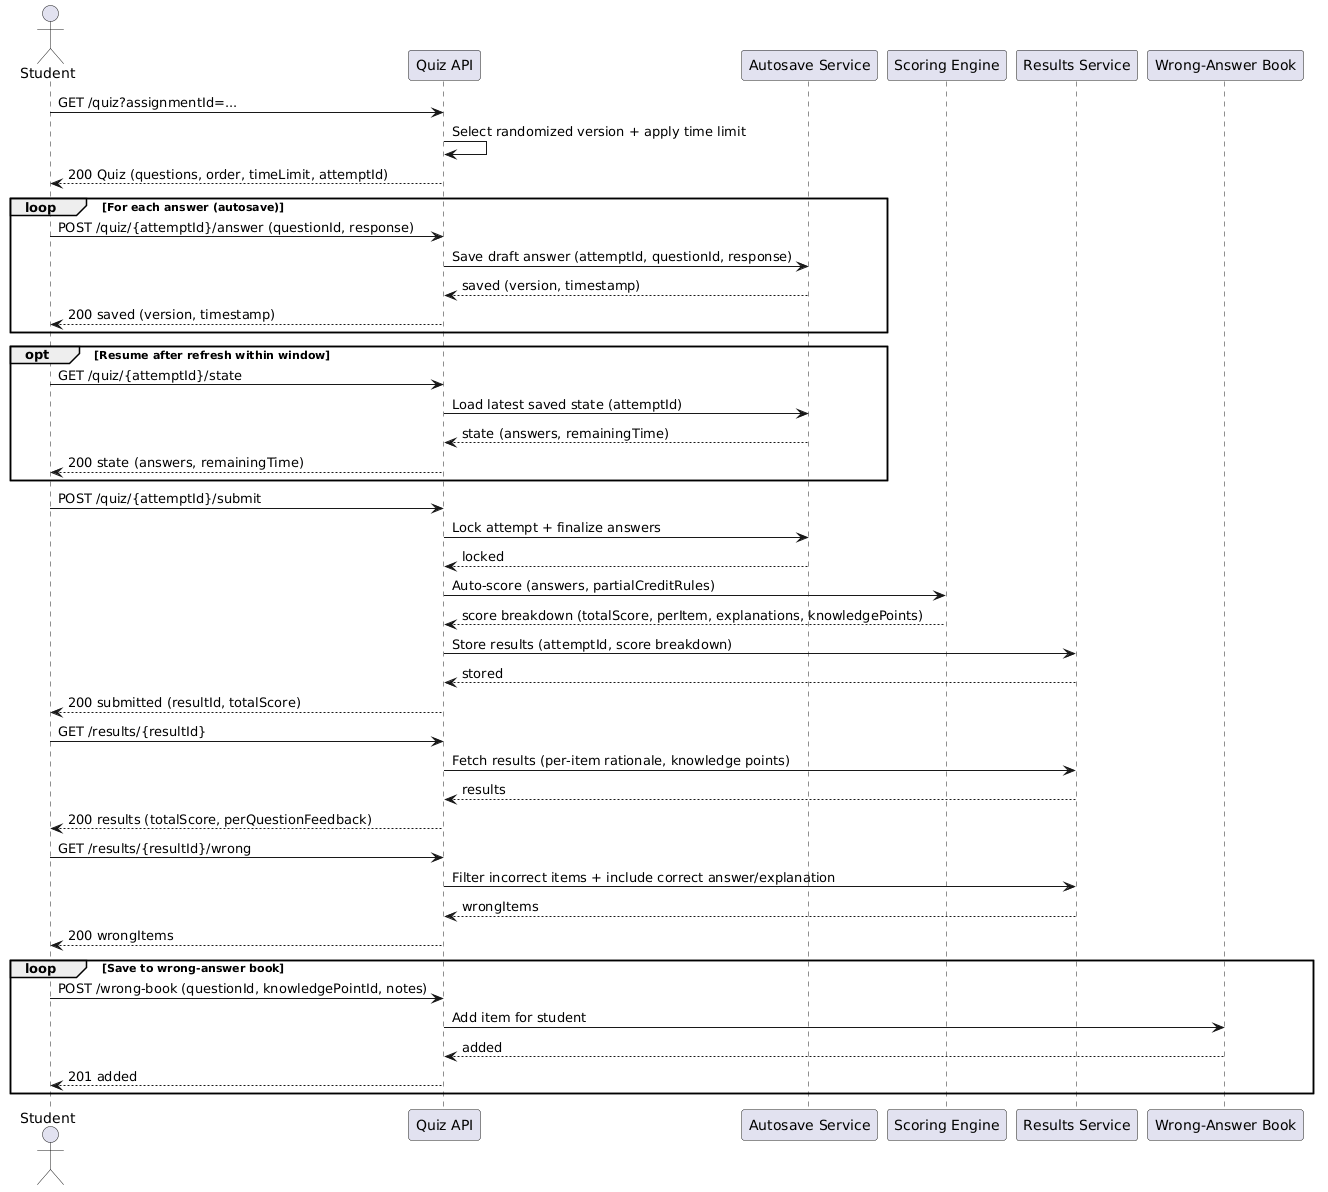

In [19]:
from utils import render_plantuml_diagram

if client and 'user_stories' in globals():
    print("--- Generating PlantUML Sequence Diagram ---")
    prompt = (
        "Create a PlantUML sequence diagram for the 'take quiz' flow.\n\n"
        "Format:\n@startuml\nactor Student\nparticipant \"Quiz API\" as API\n"
        "Student -> API: GET /quiz\nAPI --> Student: questions\n@enduml\n\n"
        "Rules:\n"
        "- Full flow: request quiz → answer → auto-score → view results → review wrong\n"
        "- Use -> for calls, --> for responses\n"
        "- At least 3 participants\n"
        "- Return ONLY valid PlantUML code\n\n"
        f"User Stories: {user_stories}"
    )
    puml = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    # Guard: only save if API returned valid PlantUML code
    if puml and not puml.startswith(("An API error", "APIFREE error", "APIFREE request failed", "Error:")):
        puml = clean_llm_output(puml, language='text')
        print("Generated PlantUML diagram:")
        print(puml)
        os.makedirs('artifacts/diagrams', exist_ok=True)
        with open('artifacts/diagrams/sequence_diagram.puml', 'w') as f:
            f.write(puml)
        print('✅ Saved: artifacts/diagrams/sequence_diagram.puml')
        render_plantuml_diagram(puml, "artifacts/diagrams/sequence_diagram.png")
    else:
        print("API request failed. Please re-run this cell.")
        print("If it still fails, please check your network connection and try re-running multiple times.")
else:
    print("Skipping step because LLM client or user_stories is not available.")

#### 2) AI generated Code

In [19]:
if client and 'user_stories' in globals():
    import json
    print("--- Generating Flask API App Code & Complementary Frontend ---")
    
    # Parse user stories
    try:
        stories_data = json.loads(user_stories) if isinstance(user_stories, str) else user_stories
        stories_list = stories_data if isinstance(stories_data, list) else stories_data.get('user_stories', [])
    except:
        print("Error parsing user stories")
        stories_list = []
    
    # Generate base app structure first
    base_app = get_completion(
        "Create a minimal Flask app skeleton with: from flask import Flask, request, jsonify, send_from_directory; app = Flask(__name__); in-memory storage using feedback_db = []; Add CORS support with from flask_cors import CORS; CORS(app); Add a health check endpoint GET /health that returns {status: ok}. Keep it under 20 lines.",
        client, model_name, api_provider, temperature=0.3
    )
    base_app = clean_llm_output(base_app, language='python')
    
    print(f"✅ Generated base app structure")
    
    # Generate endpoints for each user story iteratively
    endpoints_code = []
    for i, story in enumerate(stories_list[:3], 1):  # Limit to first 3 stories to keep it manageable
        story_text = f"Role: {story.get('role', '')}, Goal: {story.get('goal', '')}"
        print(f"  Generating endpoint {i}/3 for: {story.get('role', 'user')[:30]}...")
        
        endpoint_code = get_completion(
            f"Write 1-2 Flask endpoint functions for this user story: {story_text}. Use feedback_db list for storage. Return only the function code (e.g., @app.route decorated functions), no imports or app initialization. Keep under 25 lines. Ensure endpoints return JSON with proper status codes.",
            client, model_name, api_provider, temperature=0.3
        )
        endpoint_code = clean_llm_output(endpoint_code, language='python')
        endpoints_code.append(f"\n# Endpoint for Story {i}: {story.get('role', 'user')}\n{endpoint_code}")
    
    # Add a catch-all route to serve index.html
    frontend_route = """
# Serve frontend
@app.route('/')
def index():
    return send_from_directory('.', 'index.html')

@app.route('/<path:filename>')
def serve_static(filename):
    return send_from_directory('.', filename)
"""
    
    # Combine all code with Docker-compatible host binding
    main_py_code = base_app + "\n".join(endpoints_code) + frontend_route
    main_py_code += "\n\nif __name__ == '__main__':\n    # Bind to 0.0.0.0 to make it accessible from Docker\n    app.run(host='0.0.0.0', debug=True, port=5005)"
    
    os.makedirs('artifacts/app/flask', exist_ok=True)
    with open('artifacts/app/flask/main.py', 'w') as f:
        f.write(main_py_code)
    print('✅ Saved: artifacts/app/flask/main.py')
    
    # Extract endpoint routes for frontend integration
    import re
    route_pattern = r"@app\.route\(['\"]([^'\"]+)['\"](?:,\s*methods=\[([^\]]+)\])?\)"
    routes = re.findall(route_pattern, main_py_code)
    routes_text = ', '.join([f"{route} ({methods if methods else 'GET'})" for route, methods in routes])
    
    print(f"  Available API endpoints: {routes_text}")
    
    # Generate complementary HTML frontend that integrates with the API
    html_prompt = (
        "Generate a complete, production-ready HTML5 webpage that serves as a feedback collection system. "
        "Requirements: "
        "(1) Use Bootstrap 5 CSS framework via CDN for professional styling. "
        "(2) Include a form with input fields for: user name (text), email address (email), feedback message (textarea), and rating (select 1-5). "
        "(3) Add a Submit button that sends form data via POST request to http://127.0.0.1:5005/feedback as JSON. "
        "(4) Add a section that fetches and displays all existing feedback from http://127.0.0.1:5005/feedback using GET request. "
        "(5) Display feedback in a card or list format with name, rating, and message visible. "
        "(6) Include client-side form validation (all fields required). "
        "(7) Show success/error messages after form submission using alerts. "
        "(8) Handle network errors gracefully with user-friendly error messages. "
        "(9) Include all CSS styling inline in <style> tags. "
        "(10) Include all JavaScript logic inline in <script> tags. "
        "(11) Use Fetch API for all HTTP requests. "
        "Output ONLY the complete, valid HTML document. No explanations or markdown."
    )
    
    html_code = get_completion(
        html_prompt, client, model_name, api_provider, temperature=0.4
    )
    html_code = clean_llm_output(html_code, language='html')
    
    # Save HTML file
    with open('artifacts/app/flask/index.html', 'w') as f:
        f.write(html_code)
    print('✅ Saved: artifacts/app/flask/index.html')
    
    # Generate README.md with integration instructions
    readme_content = get_completion(
        "Write a README.md (under 250 words) for an integrated Flask feedback API with HTML frontend. Include: title, description, setup (pip install flask flask-cors), run command (python main.py), how to access the app (http://127.0.0.1:5005), and 2 curl examples for POST /feedback and GET /feedback endpoints. Also mention the interactive HTML frontend is served automatically.",
        client, model_name, api_provider, temperature=0.3
    )
    with open('artifacts/app/flask/README.md', 'w') as f:
        f.write(readme_content)
    print('✅ Saved: artifacts/app/flask/README.md')
    print("\n✅ API and Frontend code generated and saved successfully!")
else:
    print("Skipping step because LLM client or user_stories is not available.")

--- Generating Flask API App Code & Complementary Frontend ---
✅ Generated base app structure
  Generating endpoint 1/3 for: Player...
  Generating endpoint 2/3 for: Player...
  Generating endpoint 3/3 for: Product Manager...
✅ Saved: artifacts/app/flask/main.py
  Available API endpoints: /feedback ("POST"), /feedback ("GET"), /privacy/consent-info ("GET"), /privacy/consent-feedback ("POST"), /feedback ("POST"), /feedback ("GET"), / (GET), /<path:filename> (GET)
✅ Saved: artifacts/app/flask/index.html
✅ Saved: artifacts/app/flask/README.md

✅ API and Frontend code generated and saved successfully!


In [9]:
if client and os.path.exists('artifacts/app/flask/main.py'):
    print("--- Generating requirements.txt ---")
    
    # Read the app code
    with open('artifacts/app/flask/main.py', 'r') as f:
        app_code = f.read()
    
    # Extract only import statements from the beginning of the file
    import_lines = []
    for line in app_code.split('\n'):
        stripped = line.strip()
        if stripped.startswith('import ') or stripped.startswith('from '):
            import_lines.append(stripped)
        elif stripped and not stripped.startswith('#'):
            # Stop at first non-import, non-comment line
            break
    
    imports_text = '\n'.join(import_lines)
    print(f"  Found {len(import_lines)} import statement(s)")
    
    # Generate requirements based on imports only
    requirements = get_completion(
        f"Based on these Python import statements, list all required package dependencies (one per line). Include only package names, no version constraints. Remove duplicates and standard library. Import statements:\n{imports_text}",
        client, model_name, api_provider, temperature=0.3
    )
    requirements = clean_llm_output(requirements, language='text')
    
    # Parse and clean requirements
    req_lines = [line.strip() for line in requirements.split('\n')]
    req_lines = [line for line in req_lines if line and not line.startswith('#')]  # Remove empty lines and comments
    req_set = set(req_lines)  # Remove duplicates
    req_list = sorted(list(req_set))  # Sort for consistency
    
    # Reconstruct clean requirements
    clean_requirements = '\n'.join(req_list)
    
    with open('artifacts/app/flask/requirements.txt', 'w') as f:
        f.write(clean_requirements)
    print(f'✅ Saved: artifacts/app/flask/requirements.txt ({len(req_list)} packages)')
    print(f"  Packages: {', '.join(req_list)}")
else:
    print("Skipping step because Flask app is not available.")

--- Generating requirements.txt ---
  Found 2 import statement(s)
✅ Saved: artifacts/app/flask/requirements.txt (2 packages)
  Packages: flask, flask-cors


## Phase 3: Operation
AI oversees deployments, infrastructure-as-code, monitoring, and ongoing operations based on the accumulated project context. The team continues oversight and governance.

As for this practical and due to the scope of the lab, we will limit to package the application into a Docker container for easy deployment and reproducibility.

In [10]:
import os

# Generate Dockerfile for the Flask application
dockerfile_content = """FROM python:3.11-slim

# Set working directory
WORKDIR /app

# Copy requirements and install dependencies
COPY flask/requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy application files
COPY flask/ .

# Expose port
EXPOSE 5005

# Set environment variables
ENV FLASK_APP=main.py
ENV FLASK_ENV=production

# Run the application
CMD ["python", "main.py"]
"""

# Generate .dockerignore file
dockerignore_content = """__pycache__
*.pyc
*.pyo
*.pyd
.Python
env/
venv/
.venv
.git
.gitignore
.env
.DS_Store
*.egg-info
dist
build
.pytest_cache
"""

# Generate docker-compose.yml for orchestration
docker_compose_content = """version: '3.8'

services:
  flask-app:
    build:
      context: .
      dockerfile: docker/Dockerfile
    container_name: feedback-app
    ports:
      - "5005:5005"
    environment:
      - FLASK_ENV=production
      - FLASK_APP=main.py
    volumes:
      - ./flask:/app
    restart: unless-stopped
"""

# Create Docker configuration files
if os.path.exists('artifacts/app/flask/main.py'):
    print("--- Generating Docker Configuration Files ---")
    
    # Ensure docker directory exists
    os.makedirs('artifacts/app/docker', exist_ok=True)
    
    # Save Dockerfile
    with open('artifacts/app/docker/Dockerfile', 'w') as f:
        f.write(dockerfile_content)
    print('✅ Saved: artifacts/app/docker/Dockerfile')
    
    # Save .dockerignore
    with open('artifacts/app/docker/.dockerignore', 'w') as f:
        f.write(dockerignore_content)
    print('✅ Saved: artifacts/app/docker/.dockerignore')
    
    # Save docker-compose.yml in artifacts/app
    with open('artifacts/app/docker-compose.yml', 'w') as f:
        f.write(docker_compose_content)
    print('✅ Saved: artifacts/app/docker-compose.yml')
    
    print("\n--- Docker Build & Run Instructions ---")
    print("""
📦 To build and run the Docker container:

IMPORTANT: All commands must be run from the artifacts/app directory!

1. Navigate to the app directory:
   cd artifacts/app

2. Build the Docker image:
   docker build -t feedback-app:latest -f docker/Dockerfile .

3. Run the container:
   docker run -p 5005:5005 feedback-app:latest

4. Alternative: Use Docker Compose (recommended):
   docker-compose up --build

5. Access the application:
   Open http://127.0.0.1:5005 in your browser

6. View logs:
   docker logs -f feedback-app

7. Stop the container:
   docker stop feedback-app
   
8. Clean up:
   docker-compose down
    """)
    
    print("\n✅ Docker containerization setup complete!")
else:
    print("❌ Flask app not found. Please run the code generation cell first.")

--- Generating Docker Configuration Files ---
✅ Saved: artifacts/app/docker/Dockerfile
✅ Saved: artifacts/app/docker/.dockerignore
✅ Saved: artifacts/app/docker-compose.yml

--- Docker Build & Run Instructions ---

📦 To build and run the Docker container:

IMPORTANT: All commands must be run from the artifacts/app directory!

1. Navigate to the app directory:
   cd artifacts/app

2. Build the Docker image:
   docker build -t feedback-app:latest -f docker/Dockerfile .

3. Run the container:
   docker run -p 5005:5005 feedback-app:latest

4. Alternative: Use Docker Compose (recommended):
   docker-compose up --build

5. Access the application:
   Open http://127.0.0.1:5005 in your browser

6. View logs:
   docker logs -f feedback-app

7. Stop the container:
   docker stop feedback-app
   
8. Clean up:
   docker-compose down
    

✅ Docker containerization setup complete!
